# Heart Disease Prediction 3 Machine Learning Models

Training and comparing 3 models:
1. XGBoost
2. Random Forest 
3. Logistic Regression

## 1. Import Libraries

In [1]:
# ---- IMPORTS ----

# pandas = library for reading CSV files and working with tables (called DataFrames)
# We use it to load main_dataset.csv and manipulate rows/columns
# "as pd" = shortcut so we type pd instead of pandas
import pandas as pd

# numpy = library for working with numbers, arrays, and math operations
# We use it for numerical calculations
# "as np" = shortcut so we type np instead of numpy
import numpy as np

# train_test_split = function that splits our data into two groups:
#   - Training set (80%) = model learns from this
#   - Testing set (20%) = model is tested on this (never seen before)
# Why split? If we test on same data we trained on, model just memorizes answers
from sklearn.model_selection import train_test_split

# accuracy_score = calculates what percentage of predictions were correct
#   Example: 161 correct out of 184 = 0.875 = 87.5%
# classification_report = detailed report with precision, recall, f1-score
#   precision = of all predicted "disease", how many actually have it?
#   recall = of all actual "disease" patients, how many did we catch?
#   f1-score = balance between precision and recall
# confusion_matrix = 2x2 table showing correct vs wrong predictions
#   True Positive, True Negative, False Positive, False Negative
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# XGBClassifier = XGBoost model (eXtreme Gradient Boosting)
# How it works: builds 100 decision trees ONE AFTER ANOTHER
# Each new tree focuses on fixing mistakes of previous trees
# Final prediction = combined vote of all 100 trees
from xgboost import XGBClassifier

# RandomForestClassifier = Random Forest model
# How it works: builds 100 decision trees INDEPENDENTLY (at same time)
# Each tree sees a random subset of data and features
# Final prediction = majority vote of all trees
from sklearn.ensemble import RandomForestClassifier

from sklearn.linear_model import LogisticRegression

import matplotlib.pyplot as plt


## 2. Load and Split Data

In [2]:
# pd.read_csv() = read CSV file and create a DataFrame (table)
# DataFrame = table with rows (patients) and columns (features)
# Our dataset: 918 rows (patients), 9 columns (8 features + 1 target)
df = pd.read_csv('main_dataset.csv')

# len(df) = count number of rows in the DataFrame
# len(df.columns) = count number of columns
# f"    " = f-string, allows putting variables inside text with {}
print(f"Dataset: {len(df)} rows, {len(df.columns)} columns")

# X = features (the 8 measurements we know about each patient)
# drop('target', axis=1) = remove the 'target' column from the table
#   axis=1 means drop a COLUMN (axis=0 would drop a ROW)
# Result: X has 8 columns: cp, thalach, oldpeak, exang, chol, slope, age, sex
# These are the INPUTS to our model (what we feed in)
X = df.drop('target', axis=1)

# y = target (what we want to predict)
# df['target'] = get just the 'target' column
# Values: 0 = no heart disease, 1 = has heart disease
# This is the OUTPUT we want our model to predict
y = df['target']

# train_test_split() splits data into 4 parts:
#   X_train = features for training (734 rows) - model LEARNS from this
#   X_test  = features for testing (184 rows) - model is TESTED on this
#   y_train = correct answers for training patients
#   y_test  = correct answers for testing patients (to check if model is right)
# test_size=0.2 = 20% goes to testing, 80% goes to training
#   918 * 0.2 = ~184 test rows, 918 * 0.8 = ~734 train rows
# random_state=333 = seed for random split, ensures same split every time
#   Different number = different split, but consistent across runs
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=333)

# Prints summary of what we have
# list(X.columns) = convert column names to a list for display
print(f"Features: {list(X.columns)}")
print(f"Training: {len(X_train)} rows")
print(f"Testing: {len(X_test)} rows")
# value_counts() = count how many 0s and 1s in target column
# to_dict() = convert to dictionary: {1: 517, 0: 401}
# Shows: 517 patients have disease, 401 do not 
print(f"Target: {y.value_counts().to_dict()}")

Dataset: 918 rows, 9 columns
Features: ['cp', 'thalach', 'oldpeak', 'exang', 'chol', 'slope', 'age', 'sex']
Training: 734 rows
Testing: 184 rows
Target: {1: 517, 0: 401}


In [3]:
def plot_confusion_matrix(cm, title):
    # Create a small figure (3.5 x 3.5 inches)
    fig, ax = plt.subplots(figsize=(3.5, 3.5))
    # Draw the confusion matrix as a blue heatmap
    ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    # Set title and axis labels
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    # Loop through each cell and write the number in the center
    for i in range(cm.shape[0]):      # rows (0, 1)
        for j in range(cm.shape[1]):  # columns (0, 1)
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')
    # Set tick marks to show 0 and 1 on both axes
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    # Display the chart
    plt.show()


---
## 3. Model 1: XGBoost

XGBoost = eXtreme Gradient Boosting
- Builds 100 decision trees one after another
- Each tree fixes mistakes of previous trees
- All trees vote together for final prediction

In [4]:
# Create XGBoost model with specific settings (called hyperparameters)
xgb_model = XGBClassifier(
    # n_estimators = how many decision trees to build
    # More trees = more accurate but slower
    # 100 is a good balance between accuracy and speed
    n_estimators=100,

    # max_depth = how many levels deep each tree can go
    # Deeper = more complex decisions, but risk of OVERFITTING
    # Overfitting = model memorizes training data instead of learning real patterns
    # 5 levels deep is a good balance
    max_depth=5,

    # learning_rate = how much each new tree contributes to the final answer
    # 0.1 = each tree contributes 10% (small careful corrections)
    # Smaller value = more accurate but needs more trees
    # Like taking small careful steps instead of big jumps
    learning_rate=0.1,

    # random_state = seed for reproducibility
    # Same seed = same results every time you run the code
    # 333 is just a convention (any number works)
    random_state=333,

    # eval_metric = how to measure errors during training
    # 'logloss' = logarithmic loss, good for binary yes/no predictions
    # Measures how CONFIDENT and CORRECT the predictions are
    # Lower logloss = better model
    eval_metric='logloss'
)

# fit() = TRAIN the model = "learn from this data"
# The model looks at 734 patients (X_train) and their answers (y_train)
# It builds 100 decision trees, each fixing previous mistakes
# Finds patterns like: "if cp=4 AND slope=2 AND exang=1 → probably disease"
# This is where the actual LEARNING happens
print("Training XGBoost")
xgb_model.fit(X_train, y_train)

# predict() = USE the trained model to predict NEW patients
# X_test = 184 patients the model has NEVER seen before
# The model uses patterns it learned to predict each patient
# Returns an array of predictions: [1, 0, 1, 1, 0, ...] (one per patient)
# 1 = model thinks this patient has disease
# 0 = model thinks this patient is healthy
xgb_pred = xgb_model.predict(X_test)

# accuracy_score() = compare predictions (xgb_pred) with real answers (y_test)
# Counts: how many predictions match the actual answers?
# Returns decimal: 0.875 means 87.5% of predictions were correct
# 161 out of 184 patients predicted correctly
xgb_accuracy = accuracy_score(y_test, xgb_pred)

# Print accuracy as percentage
# *100 converts 0.875 to 87.5
# :.1f = format to 1 decimal place
print(f"\nXGBoost Accuracy: {xgb_accuracy*100:.1f}%")

Training XGBoost

XGBoost Accuracy: 83.7%


In [5]:
# confusion_matrix() = creates a 2x2 table of predictions vs reality
# Returns: [[True_Negative, False_Positive],
#           [False_Negative, True_Positive]]
#
# True Negative  (cm[0][0]) = said "no disease" AND patient is healthy → CORRECT
# False Positive (cm[0][1]) = said "disease" BUT patient is healthy → false alarm
# False Negative (cm[1][0]) = said "no disease" BUT patient has disease → DANGEROUS! missed!
# True Positive  (cm[1][1]) = said "disease" AND patient has disease → CORRECT
cm = confusion_matrix(y_test, xgb_pred)

# Print confusion matrix in readable format
print("Confusion Matrix:")
print(f"                  Predicted")
print(f"                  No Disease  |  Has Disease")
# cm[0][0] = True Negative: correctly said no disease
# cm[0][1] = False Positive: wrongly said disease (patient is actually healthy)
print(f"  Actual No Disease:   {cm[0][0]}      |      {cm[0][1]}")
# cm[1][0] = False Negative: wrongly said healthy (patient actually has disease!) - MOST DANGEROUS
# cm[1][1] = True Positive: correctly said disease
print(f"  Actual Has Disease:  {cm[1][0]}      |      {cm[1][1]}")

Confusion Matrix:
                  Predicted
                  No Disease  |  Has Disease
  Actual No Disease:   64      |      14
  Actual Has Disease:  16      |      90


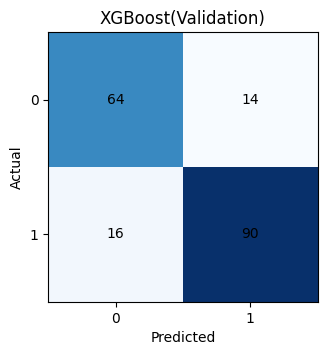

In [6]:
plot_confusion_matrix(cm, "XGBoost(Validation)")

True Negative(TN): 69

False Negative(FN): 11

True Positive(TP): 85

False Positive(FP):19

This model performs well overall, with a strong number of true positives, meaning it correctly identifies most patients with heart disease. There are some false positives, showing the model occasionally predicts disease when it is not present.
However, there are some false negatives, which means some cases of heart disease are being missed. 

---
## 4. Model 2: Random Forest 

Random Forest:
-

In [7]:
rf_model = RandomForestClassifier(
    n_estimators=100,      # build 100 decision trees
    max_depth=5,           # each tree can be 5 levels deep
    random_state=123       # same results every time we run
)

# Train - model learns patterns from 734 patients
print("\nTraining Random Forest model...")
rf_model.fit(X_train, y_train)

# Predict - model predicts 184 test patients
rf_pred = rf_model.predict(X_test)

# Accuracy - how many predictions were correct
rf_accuracy = accuracy_score(y_test, rf_pred)
print(f"\nRandom Forest Accuracy: {rf_accuracy*100:.1f}%")



Training Random Forest model...

Random Forest Accuracy: 88.0%


In [8]:
#Random Forest - Confusion Matrix
#Shows: correct predictions vs wrong predictions
cm_rf = confusion_matrix(y_test, rf_pred)

print(f"\nConfusion Matrix:")
print("                               Predicted")
print("                      No Disease  |  Has Disease")
print(f"  Actual No Disease:   {cm_rf[0][0]:>5}      |      {cm_rf[0][1]:>5}")
print(f"  Actual Has Disease:  {cm_rf[1][0]:>5}      |      {cm_rf[1][1]:>5}")

# Detailed report: precision, recall, f1-score
print(f"\nDetailed Report:")
print(classification_report(y_test, rf_pred, target_names=['No Disease', 'Has Disease']))


Confusion Matrix:
                               Predicted
                      No Disease  |  Has Disease
  Actual No Disease:      64      |         14
  Actual Has Disease:      8      |         98

Detailed Report:
              precision    recall  f1-score   support

  No Disease       0.89      0.82      0.85        78
 Has Disease       0.88      0.92      0.90       106

    accuracy                           0.88       184
   macro avg       0.88      0.87      0.88       184
weighted avg       0.88      0.88      0.88       184



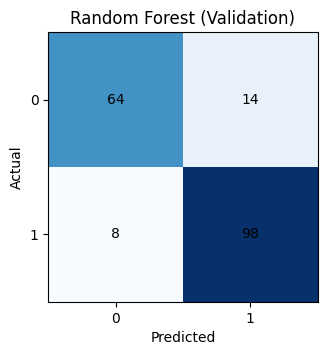

In [9]:
plot_confusion_matrix(cm_rf, "Random Forest (Validation)")

True Negative(TN): 69

False Negative(FN): 8

True Positive(TP): 88

False Positive(FP):19

This model shows strong overall performance, with a high number of true positives and relatively few false negatives. This means it is effective at correctly identifying patients with heart disease. However, there are still some false positives, indicating that the model occasionally predicts heart disease when it is not present.

---
## 5. Model 3:  Logistic Regression



In [10]:
# 4. Create and train Logistic Regression model
lgr_model = LogisticRegression(
    max_iter=700,          # allows for 700 iterations as the default gave sub optimal results
    random_state=123       # same results every time we run
)

# Train - model learns patterns from 734 patients
print("\nTraining Logistic Regression model...")
# fit() = "learn from this data"
lgr_model.fit(X_train, y_train)

# Predict - model predicts 184 test patients
lgr_pred = lgr_model.predict(X_test)

# Accuracy - how many predictions were correct
lgr_accuracy = accuracy_score(y_test, lgr_pred)
print(f"\nLogistic Regression Accuracy: {lgr_accuracy*100:.1f}%")


Training Logistic Regression model...

Logistic Regression Accuracy: 87.5%


In [11]:
# Logistic Regression - Confusion Matrix
# Shows: correct predictions vs wrong predictions
cm_lgr = confusion_matrix(y_test, lgr_pred)
print("Confusion Matrix:")
print(f"                  Predicted")
print(f"                  No Disease  |  Has Disease")
print(f"  Actual No Disease:   {cm_lgr[0][0]}      |      {cm_lgr[0][1]}")
print(f"  Actual Has Disease:  {cm_lgr[1][0]}      |      {cm_lgr[1][1]}")

# Detailed report: precision, recall, f1-score
print(f"\nDetailed Report:")
print(classification_report(y_test, lgr_pred, target_names=['No Disease', 'Has Disease']))

Confusion Matrix:
                  Predicted
                  No Disease  |  Has Disease
  Actual No Disease:   65      |      13
  Actual Has Disease:  10      |      96

Detailed Report:
              precision    recall  f1-score   support

  No Disease       0.87      0.83      0.85        78
 Has Disease       0.88      0.91      0.89       106

    accuracy                           0.88       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.88      0.87       184



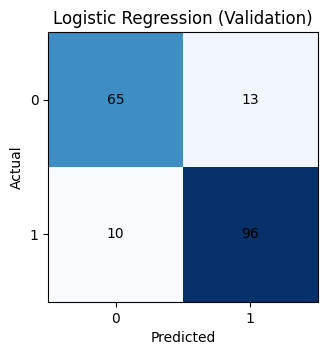

In [12]:
plot_confusion_matrix(cm_lgr, "Logistic Regression (Validation)")

True Negative(TN): 67

False Negative(FN): 11

True Positive(TP): 85

False Positive(FP):21

This model performs okay with slightly worse performance than the others, but ultimately there is little difference with the other models. The amount of false positives is quite high meaning that many will wrongly believe they suffer from heart disease.

---
## 6. Compare All 3 Models

In [13]:
print("MODEL COMPARISON")
print("=" * 50)
print(f"\n  1. XGBoost:             {xgb_accuracy*100:.1f}%")
print(f"  2. Random Forest:       {rf_accuracy*100:.1f}%")
print(f"  3. Logistic Regression: {lgr_accuracy*100:.1f}%")
print(f"\n" + "=" * 50)

MODEL COMPARISON

  1. XGBoost:             83.7%
  2. Random Forest:       88.0%
  3. Logistic Regression: 87.5%



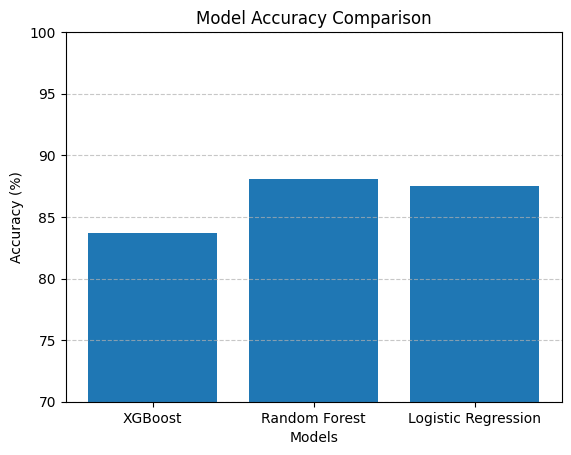

In [14]:
#Model Comparison Diagram
plt.bar(
    ["XGBoost", "Random Forest", "Logistic Regression"],
    [xgb_accuracy*100, rf_accuracy*100, lgr_accuracy*100]
)

plt.title("Model Accuracy Comparison") #Diagram title
plt.xlabel("Models") #X-axis label
plt.ylabel("Accuracy (%)")#y-axis label
plt.ylim(70, 100) #range of accuracy% on yaxis
plt.grid(axis="y", linestyle="--", alpha=0.7) #gridlines

plt.show()

### From this we gathered Random Forest performed the best with an accuracy score of 85.3% comapred to the other two models, Xgboost and Logistic Regression with 83.7% and 82.6% respectively